In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
import os
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt
import optuna

# Load Data

In [3]:
image_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

In [4]:
dataset_path = 'C:\\Users\\rohit\\Downloads\\training\\dataset'
dataset = datasets.ImageFolder(root = dataset_path, transform = image_transform)
len(dataset)

2300

In [5]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [6]:
num_classes = len(dataset.classes)
num_classes

6

In [7]:
train_size = int(0.75 * len(dataset))
val_size = len(dataset) - train_size

train_size, val_size

(1725, 575)

In [8]:
from torch.utils.data import random_split
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [9]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True, num_workers = 0)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = True, num_workers = 0)

In [10]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [11]:
labels[9]

tensor(3)

In [12]:
images[9]

tensor([[[-2.1179, -2.1179, -2.1179,  ..., -1.8782, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -1.7925, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -1.6898, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -1.8439,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -1.8782,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -1.9638,  ..., -2.1179, -2.1179, -2.1179]],

        [[-2.0357, -2.0357, -2.0357,  ..., -1.7906, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -1.6681, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -1.5630, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -1.7556,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -1.8081,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -1.8782,  ..., -2.0357, -2.0357, -2.0357]],

        [[-1.8044, -1.8044, -1.8044,  ..., -1.5430, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.8044,  ..., -1

In [13]:
images[9].shape

torch.Size([3, 224, 224])

In [14]:
images[9].permute(1, 2, 0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


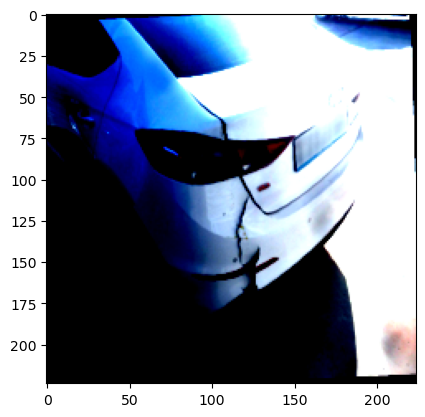

In [15]:
plt.imshow(images[9].permute(1, 2, 0))
plt.show()

# Model Training with CNN

In [16]:
class CarClassifierCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, stride = 1, padding = 1), # (16, 224, 224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0), # (32, 112, 112)
            nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, stride = 1, padding = 1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0), # (32, 56, 56)
            nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0), # (64, 28, 28)
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )


    def forward(self, x):
        x = self.network(x)
        return x

In [17]:
model = CarClassifierCNN(num_classes = num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [18]:
labels.size(0)

32

In [19]:
def train_model(model, criterion, optimizer, epochs = 5):
    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            if (batch_num + 1) % 10 == 0:
                print(f'Batch : {batch_num}, Epoch : {epoch + 1}, Loss : {loss.item():0.2f}')
            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch [{epoch + 1} / {epochs}], Avg Loss : {epoch_loss:.4f}')

        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
            print(f'Validation Accuracy : {100 * correct / total:.2f}%')

    end = time.time()
    print(f'Execution Time : {end - start} seconds')
    return all_labels, all_predictions

In [20]:
all_labels, all_predictions = train_model(model, criterion, optimizer, epochs = 5)

Batch : 9, Epoch : 1, Loss : 1.80
Batch : 19, Epoch : 1, Loss : 1.78
Batch : 29, Epoch : 1, Loss : 1.72
Batch : 39, Epoch : 1, Loss : 1.51
Batch : 49, Epoch : 1, Loss : 1.50
Epoch [1 / 5], Avg Loss : 1.8230
Validation Accuracy : 37.74%
Batch : 9, Epoch : 2, Loss : 1.36
Batch : 19, Epoch : 2, Loss : 1.28
Batch : 29, Epoch : 2, Loss : 0.94
Batch : 39, Epoch : 2, Loss : 1.18
Batch : 49, Epoch : 2, Loss : 1.28
Epoch [2 / 5], Avg Loss : 1.3383
Validation Accuracy : 49.22%
Batch : 9, Epoch : 3, Loss : 1.10
Batch : 19, Epoch : 3, Loss : 1.17
Batch : 29, Epoch : 3, Loss : 1.12
Batch : 39, Epoch : 3, Loss : 1.10
Batch : 49, Epoch : 3, Loss : 1.16
Epoch [3 / 5], Avg Loss : 1.2056
Validation Accuracy : 53.22%
Batch : 9, Epoch : 4, Loss : 1.15
Batch : 19, Epoch : 4, Loss : 1.15
Batch : 29, Epoch : 4, Loss : 1.14
Batch : 39, Epoch : 4, Loss : 1.19
Batch : 49, Epoch : 4, Loss : 1.16
Epoch [4 / 5], Avg Loss : 1.1312
Validation Accuracy : 49.22%
Batch : 9, Epoch : 5, Loss : 1.26
Batch : 19, Epoch : 5,

# Model Training with CNN and Regularization

In [21]:
class CarClassifierCNNWithRegularization(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, stride = 1, padding = 1), # (16, 224, 224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0), # (32, 112, 112)
            nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, stride = 1, padding = 1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0), # (32, 56, 56)
            nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, stride = 1, padding = 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0), # (64, 28, 28)
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )


    def forward(self, x):
        x = self.network(x)
        return x

In [22]:
model = CarClassifierCNNWithRegularization(num_classes = num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001, weight_decay = 1e-4)

train_model(model, criterion, optimizer, epochs = 10)

Batch : 9, Epoch : 1, Loss : 9.08
Batch : 19, Epoch : 1, Loss : 3.30
Batch : 29, Epoch : 1, Loss : 1.73
Batch : 39, Epoch : 1, Loss : 1.48
Batch : 49, Epoch : 1, Loss : 1.50
Epoch [1 / 10], Avg Loss : 7.2872
Validation Accuracy : 38.61%
Batch : 9, Epoch : 2, Loss : 1.45
Batch : 19, Epoch : 2, Loss : 1.58
Batch : 29, Epoch : 2, Loss : 1.59
Batch : 39, Epoch : 2, Loss : 1.61
Batch : 49, Epoch : 2, Loss : 1.23
Epoch [2 / 10], Avg Loss : 1.4637
Validation Accuracy : 48.35%
Batch : 9, Epoch : 3, Loss : 1.33
Batch : 19, Epoch : 3, Loss : 1.38
Batch : 29, Epoch : 3, Loss : 1.58
Batch : 39, Epoch : 3, Loss : 1.46
Batch : 49, Epoch : 3, Loss : 1.09
Epoch [3 / 10], Avg Loss : 1.3412
Validation Accuracy : 47.30%
Batch : 9, Epoch : 4, Loss : 1.22
Batch : 19, Epoch : 4, Loss : 1.05
Batch : 29, Epoch : 4, Loss : 1.36
Batch : 39, Epoch : 4, Loss : 1.08
Batch : 49, Epoch : 4, Loss : 1.15
Epoch [4 / 10], Avg Loss : 1.2698
Validation Accuracy : 53.57%
Batch : 9, Epoch : 5, Loss : 1.27
Batch : 19, Epoch 

([np.int64(0),
  np.int64(3),
  np.int64(4),
  np.int64(3),
  np.int64(1),
  np.int64(5),
  np.int64(0),
  np.int64(0),
  np.int64(5),
  np.int64(3),
  np.int64(5),
  np.int64(2),
  np.int64(5),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64(3),
  np.int64(4),
  np.int64(4),
  np.int64(1),
  np.int64(0),
  np.int64(4),
  np.int64(3),
  np.int64(0),
  np.int64(3),
  np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(2),
  np.int64(2),
  np.int64(1),
  np.int64(5),
  np.int64(2),
  np.int64(4),
  np.int64(4),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(2),
  np.int64(5),
  np.int64(1),
  np.int64(1),
  np.int64(4),
  np.int64(1),
  np.int64(5),
  np.int64(4),
  np.int64(3),
  np.int64(2),
  np.int64(0),
  np.int64(4),
  np.int64(5),
  np.int64(5),
  np.int64(2),
  np.int64(2),
  np.int64

# Transfer learning with EfficientNet

In [23]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights = 'DEFAULT')
        in_features = self.model.classifier[1].in_features

        for params in self.model.parameters():
            params.requires_grad = False

        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )


    def forward(self, x):
        x = self.model(x)
        return x

In [24]:
model = CarClassifierEfficientNet(num_classes = num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr = 0.001)

train_model(model, criterion, optimizer, epochs = 10)

Batch : 9, Epoch : 1, Loss : 1.81
Batch : 19, Epoch : 1, Loss : 1.65
Batch : 29, Epoch : 1, Loss : 1.31
Batch : 39, Epoch : 1, Loss : 1.51
Batch : 49, Epoch : 1, Loss : 1.30
Epoch [1 / 10], Avg Loss : 1.4889
Validation Accuracy : 63.48%
Batch : 9, Epoch : 2, Loss : 1.24
Batch : 19, Epoch : 2, Loss : 1.09
Batch : 29, Epoch : 2, Loss : 1.35
Batch : 39, Epoch : 2, Loss : 1.09
Batch : 49, Epoch : 2, Loss : 1.12
Epoch [2 / 10], Avg Loss : 1.1371
Validation Accuracy : 62.96%
Batch : 9, Epoch : 3, Loss : 0.84
Batch : 19, Epoch : 3, Loss : 1.04
Batch : 29, Epoch : 3, Loss : 1.13
Batch : 39, Epoch : 3, Loss : 1.14
Batch : 49, Epoch : 3, Loss : 1.01
Epoch [3 / 10], Avg Loss : 1.0295
Validation Accuracy : 67.65%
Batch : 9, Epoch : 4, Loss : 0.94
Batch : 19, Epoch : 4, Loss : 0.74
Batch : 29, Epoch : 4, Loss : 1.06
Batch : 39, Epoch : 4, Loss : 0.99
Batch : 49, Epoch : 4, Loss : 0.92
Epoch [4 / 10], Avg Loss : 0.9500
Validation Accuracy : 66.61%
Batch : 9, Epoch : 5, Loss : 0.88
Batch : 19, Epoch 

([np.int64(5),
  np.int64(0),
  np.int64(5),
  np.int64(2),
  np.int64(2),
  np.int64(0),
  np.int64(4),
  np.int64(5),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(4),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(4),
  np.int64(4),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(5),
  np.int64(3),
  np.int64(5),
  np.int64(5),
  np.int64(3),
  np.int64(1),
  np.int64(0),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(4),
  np.int64(1),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(0),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(0),
  np.int64(0),
  np.int64(3),
  np.int64(0),
  np.int64(5),
  np.int64(2),
  np.int64(2),
  np.int64(2),
  np.int64(3),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(5),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64

# Transfer learning with ResNet

In [25]:
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.resnet50(weights = 'DEFAULT')

        for params in self.model.parameters():
            params.requires_grad = False

        for params in self.model.layer4.parameters():
            params.requires_grad = True

        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.model.fc.in_features, num_classes)
        )


    def forward(self, x):
        x = self.model(x)
        return x

In [26]:
model = CarClassifierResNet(num_classes = num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr = 0.001)

train_model(model, criterion, optimizer, epochs = 10)

Batch : 9, Epoch : 1, Loss : 1.50
Batch : 19, Epoch : 1, Loss : 0.67
Batch : 29, Epoch : 1, Loss : 0.69
Batch : 39, Epoch : 1, Loss : 0.63
Batch : 49, Epoch : 1, Loss : 0.62
Epoch [1 / 10], Avg Loss : 0.8859
Validation Accuracy : 71.30%
Batch : 9, Epoch : 2, Loss : 0.40
Batch : 19, Epoch : 2, Loss : 0.48
Batch : 29, Epoch : 2, Loss : 0.69
Batch : 39, Epoch : 2, Loss : 0.46
Batch : 49, Epoch : 2, Loss : 0.51
Epoch [2 / 10], Avg Loss : 0.4512
Validation Accuracy : 73.57%
Batch : 9, Epoch : 3, Loss : 0.45
Batch : 19, Epoch : 3, Loss : 0.51
Batch : 29, Epoch : 3, Loss : 0.35
Batch : 39, Epoch : 3, Loss : 0.69
Batch : 49, Epoch : 3, Loss : 0.22
Epoch [3 / 10], Avg Loss : 0.3239
Validation Accuracy : 80.35%
Batch : 9, Epoch : 4, Loss : 0.31
Batch : 19, Epoch : 4, Loss : 0.31
Batch : 29, Epoch : 4, Loss : 0.26
Batch : 39, Epoch : 4, Loss : 0.16
Batch : 49, Epoch : 4, Loss : 0.49
Epoch [4 / 10], Avg Loss : 0.2624
Validation Accuracy : 78.96%
Batch : 9, Epoch : 5, Loss : 0.14
Batch : 19, Epoch 

([np.int64(5),
  np.int64(3),
  np.int64(3),
  np.int64(2),
  np.int64(3),
  np.int64(5),
  np.int64(4),
  np.int64(2),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(2),
  np.int64(4),
  np.int64(2),
  np.int64(1),
  np.int64(2),
  np.int64(5),
  np.int64(1),
  np.int64(2),
  np.int64(0),
  np.int64(4),
  np.int64(0),
  np.int64(3),
  np.int64(0),
  np.int64(5),
  np.int64(3),
  np.int64(0),
  np.int64(3),
  np.int64(3),
  np.int64(3),
  np.int64(1),
  np.int64(0),
  np.int64(2),
  np.int64(5),
  np.int64(0),
  np.int64(0),
  np.int64(4),
  np.int64(2),
  np.int64(2),
  np.int64(1),
  np.int64(5),
  np.int64(5),
  np.int64(1),
  np.int64(4),
  np.int64(2),
  np.int64(4),
  np.int64(1),
  np.int64(2),
  np.int64(2),
  np.int64(5),
  np.int64(5),
  np.int64(1),
  np.int64(3),
  np.int64(0),
  np.int64(2),
  np.int64(4),
  np.int64(1),
  np.int64(4),
  np.int64(0),
  np.int64(2),
  np.int64(5),
  np.int64(1),
  np.int64(1),
  np.int64(5),
  np.int64(0),
  np.int64

# Hyperparameter Tunning using Optuna

In [27]:
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate = 0.5):
        super().__init__()
        self.model = models.resnet50(weights = 'DEFAULT')

        for params in self.model.parameters():
            params.requires_grad = False

        for params in self.model.layer4.parameters():
            params.requires_grad = True

        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )


    def forward(self, x):
        x = self.model(x)
        return x

In [28]:
def objective(trial):
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log = True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.7)

    model = CarClassifierResNet(num_classes = num_classes, dropout_rate = dropout_rate)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr = lr)

    epochs = 3
    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
        accuracy = 100 * correct / total

        trial.report(accuracy, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    end = time.time()
    print(f'Execution Time : {end - start} seconds')
    return accuracy

In [30]:
study = optuna.create_study(direction = 'maximize')
study.optimize(objective, n_trials = 5)

[I 2026-01-20 20:24:26,274] A new study created in memory with name: no-name-525e55c1-70c7-4f88-8f39-737f0ee1560c
[I 2026-01-20 21:54:03,241] Trial 0 finished with value: 78.6086956521739 and parameters: {'lr': 0.0025929025398409257, 'dropout_rate': 0.46640356047048703}. Best is trial 0 with value: 78.6086956521739.


Execution Time : 5375.894947767258 seconds


[I 2026-01-20 23:20:24,012] Trial 1 finished with value: 55.65217391304348 and parameters: {'lr': 1.5247731124311436e-05, 'dropout_rate': 0.2750727158565783}. Best is trial 0 with value: 78.6086956521739.


Execution Time : 5179.742129802704 seconds


[I 2026-01-21 00:03:10,178] Trial 2 finished with value: 73.91304347826087 and parameters: {'lr': 7.947515383254996e-05, 'dropout_rate': 0.359046289896634}. Best is trial 0 with value: 78.6086956521739.


Execution Time : 2565.096042394638 seconds


[I 2026-01-21 00:46:25,773] Trial 3 finished with value: 79.30434782608695 and parameters: {'lr': 0.002253216516599012, 'dropout_rate': 0.31319208896075595}. Best is trial 3 with value: 79.30434782608695.


Execution Time : 2594.8899698257446 seconds


[I 2026-01-21 01:43:10,684] Trial 4 finished with value: 77.3913043478261 and parameters: {'lr': 0.00017477461948060317, 'dropout_rate': 0.39038496818697}. Best is trial 3 with value: 79.30434782608695.


Execution Time : 3404.1764838695526 seconds


In [31]:
model = CarClassifierResNet(num_classes = num_classes, dropout_rate = 0.2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr = 0.005)

labels, predictions = train_model(model, criterion, optimizer, epochs = 10)

Batch : 9, Epoch : 1, Loss : 1.45
Batch : 19, Epoch : 1, Loss : 0.77
Batch : 29, Epoch : 1, Loss : 0.84
Batch : 39, Epoch : 1, Loss : 0.65
Batch : 49, Epoch : 1, Loss : 0.63
Epoch [1 / 10], Avg Loss : 0.9610
Validation Accuracy : 70.43%
Batch : 9, Epoch : 2, Loss : 0.74
Batch : 19, Epoch : 2, Loss : 0.51
Batch : 29, Epoch : 2, Loss : 0.64
Batch : 39, Epoch : 2, Loss : 0.75
Batch : 49, Epoch : 2, Loss : 0.50
Epoch [2 / 10], Avg Loss : 0.5617
Validation Accuracy : 76.00%
Batch : 9, Epoch : 3, Loss : 0.39
Batch : 19, Epoch : 3, Loss : 0.20
Batch : 29, Epoch : 3, Loss : 0.25
Batch : 39, Epoch : 3, Loss : 0.43
Batch : 49, Epoch : 3, Loss : 0.38
Epoch [3 / 10], Avg Loss : 0.3698
Validation Accuracy : 74.96%
Batch : 9, Epoch : 4, Loss : 0.27
Batch : 19, Epoch : 4, Loss : 0.10
Batch : 29, Epoch : 4, Loss : 0.35
Batch : 39, Epoch : 4, Loss : 0.21
Batch : 49, Epoch : 4, Loss : 0.69
Epoch [4 / 10], Avg Loss : 0.2735
Validation Accuracy : 78.78%
Batch : 9, Epoch : 5, Loss : 0.12
Batch : 19, Epoch 

 # Model Evaluation and Export

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [41]:
report = classification_report(labels, predictions)
print(report)

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       125
           1       0.70      0.74      0.72       106
           2       0.89      0.84      0.87       127
           3       0.78      0.71      0.75        66
           4       0.72      0.75      0.73        77
           5       0.82      0.82      0.82        74

    accuracy                           0.80       575
   macro avg       0.79      0.79      0.79       575
weighted avg       0.80      0.80      0.80       575



In [42]:
class_names = dataset.classes
class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

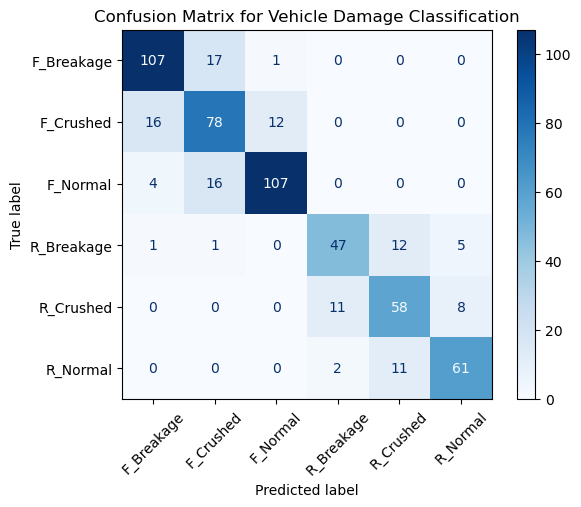

In [47]:
conf_matrix = confusion_matrix(labels, predictions, labels = np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = class_names)
disp.plot(cmap = plt.cm.Blues, xticks_rotation = 45)
plt.title('Confusion Matrix for Vehicle Damage Classification')
plt.show()

In [48]:
torch.save(model.state_dict(), 'saved_model.pth')

In [49]:
import os
print(os.getcwd())


C:\Users\rohit
